# Generate Training Curves

Loads `outputs/logs/{baseline,guided}_history.json` and plots:
1. Train loss over epochs (both models)
2. Val DICE over epochs (both models)
3. Learning rate schedule (both models)
4. Side-by-side summary table

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

REPO_ROOT  = Path('/data/users/ssethi2/mmml_repos/guided-brightspot')
LOG_DIR    = REPO_ROOT / 'outputs' / 'logs'
CKPT_DIR   = REPO_ROOT / 'outputs' / 'checkpoints'
OUTPUT_DIR = REPO_ROOT / 'outputs' / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_INTERVAL = 5   # must match what you used during training

COLORS = {
    'baseline': '#4C72B0',   # blue
    'guided':   '#DD8452',   # orange
}

def load_history(model_name: str) -> dict | None:
    path = LOG_DIR / f'{model_name}_history.json'
    if not path.exists():
        print(f'WARNING: {path} not found — {model_name} not yet trained or log missing')
        return None
    with open(path) as f:
        return json.load(f)

baseline_hist = load_history('baseline')
guided_hist   = load_history('guided')

# Epoch axes
def train_epochs(hist):  return list(range(1, len(hist['train_loss']) + 1))
def val_epochs(hist):    return list(range(VAL_INTERVAL,
                                           len(hist['val_dice']) * VAL_INTERVAL + 1,
                                           VAL_INTERVAL))

print('Logs loaded:')
for name, hist in [('baseline', baseline_hist), ('guided', guided_hist)]:
    if hist:
        n_ep  = len(hist['train_loss'])
        n_val = len(hist['val_dice'])
        best  = max(hist['val_dice']) if hist['val_dice'] else float('nan')
        print(f'  {name}: {n_ep} train epochs, {n_val} val checkpoints, '
              f'best val DICE={best:.4f}')

Logs loaded:
  baseline: 300 train epochs, 60 val checkpoints, best val DICE=0.6252
  guided: 300 train epochs, 60 val checkpoints, best val DICE=0.6825


## 1. Training loss

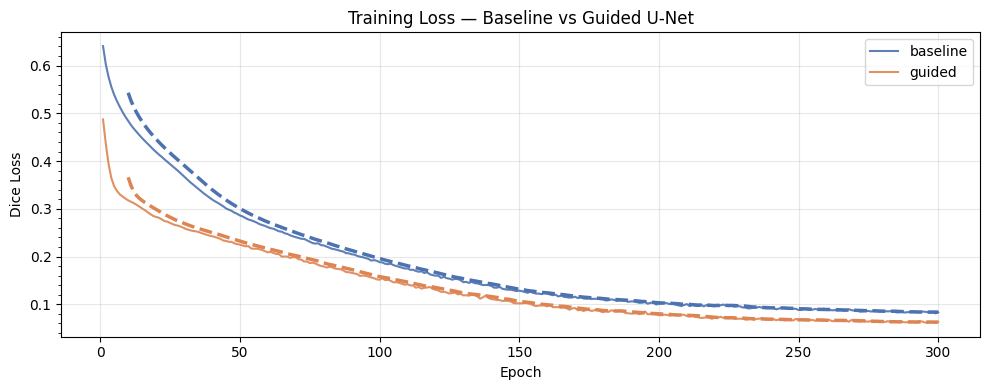

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))

for name, hist in [('baseline', baseline_hist), ('guided', guided_hist)]:
    if hist is None:
        continue
    epochs = train_epochs(hist)
    loss   = hist['train_loss']
    ax.plot(epochs, loss, color=COLORS[name], label=name, linewidth=1.5, alpha=0.9)
    # Smooth overlay (rolling mean over 10 epochs)
    if len(loss) >= 10:
        smooth = np.convolve(loss, np.ones(10)/10, mode='valid')
        ax.plot(epochs[9:], smooth, color=COLORS[name],
                linewidth=2.5, alpha=1.0, linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Dice Loss')
ax.set_title('Training Loss — Baseline vs Guided U-Net')
ax.legend()
ax.grid(alpha=0.3)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
out = OUTPUT_DIR / 'train_loss.png'
#plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
#print(f'Saved to {out}')

## 2. Validation DICE

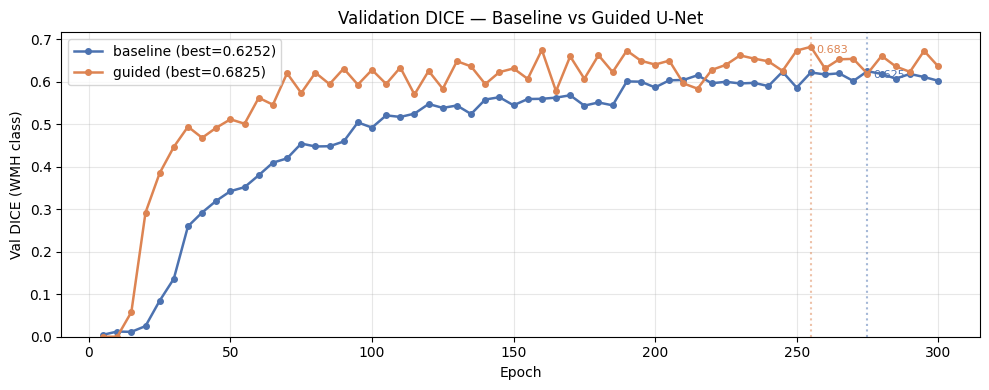

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))

for name, hist in [('baseline', baseline_hist), ('guided', guided_hist)]:
    if hist is None or not hist['val_dice']:
        continue
    epochs   = val_epochs(hist)
    val_dice = hist['val_dice']
    best_idx = int(np.argmax(val_dice))
    best_val = val_dice[best_idx]
    best_ep  = epochs[best_idx]

    ax.plot(epochs, val_dice, color=COLORS[name], marker='o',
            markersize=4, linewidth=1.8, label=f'{name} (best={best_val:.4f})')
    ax.axvline(best_ep, color=COLORS[name], linestyle=':', alpha=0.5)
    ax.annotate(f'{best_val:.3f}',
                xy=(best_ep, best_val),
                xytext=(best_ep + 2, best_val - 0.015),
                fontsize=8, color=COLORS[name])

ax.set_xlabel('Epoch')
ax.set_ylabel('Val DICE (WMH class)')
ax.set_title('Validation DICE — Baseline vs Guided U-Net')
ax.set_ylim(bottom=0)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
out = OUTPUT_DIR / 'val_dice.png'
#plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
#print(f'Saved to {out}')

## 3. Learning rate schedule

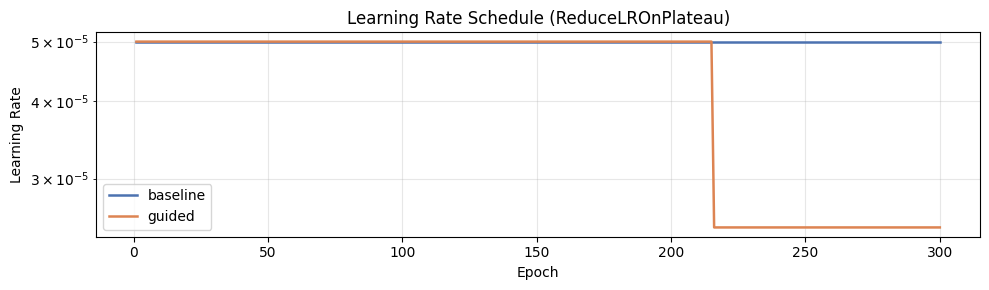

In [4]:
fig, ax = plt.subplots(figsize=(10, 3))

for name, hist in [('baseline', baseline_hist), ('guided', guided_hist)]:
    if hist is None or 'lr' not in hist or not hist['lr']:
        continue
    epochs = train_epochs(hist)
    ax.plot(epochs, hist['lr'], color=COLORS[name], label=name, linewidth=1.8)

ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule (ReduceLROnPlateau)')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
out = OUTPUT_DIR / 'lr_schedule.png'
#plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
#print(f'Saved to {out}')

## 4. Combined 3-panel figure (for presentation)

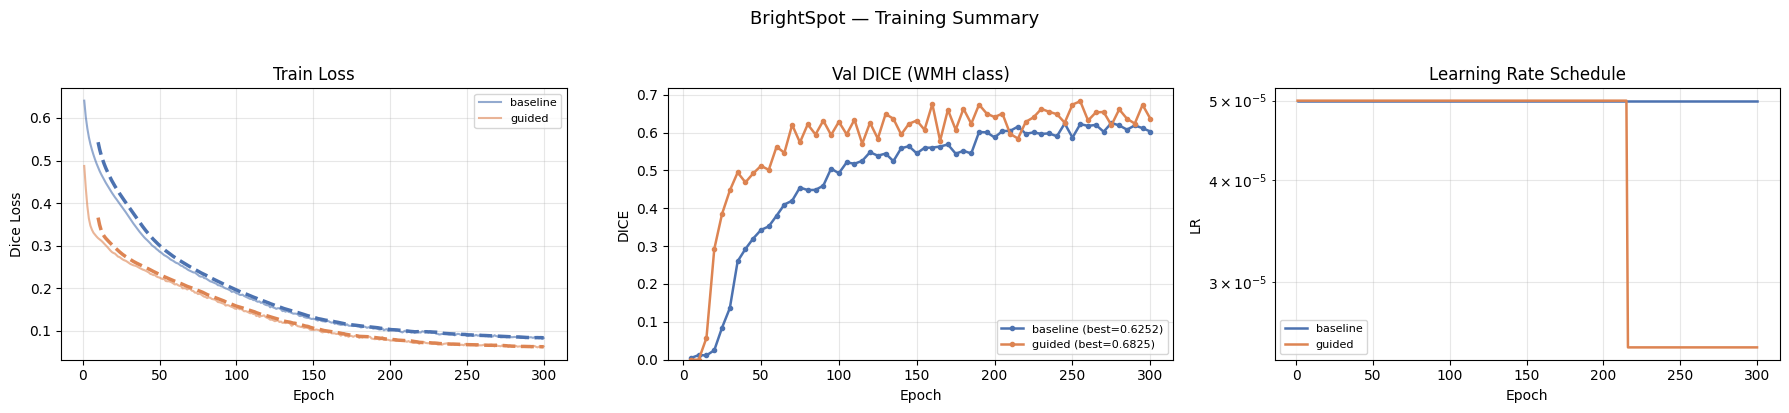

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Panel 1 — train loss
for name, hist in [('baseline', baseline_hist), ('guided', guided_hist)]:
    if hist is None: continue
    epochs = train_epochs(hist)
    axes[0].plot(epochs, hist['train_loss'], color=COLORS[name],
                 label=name, linewidth=1.5, alpha=0.6)
    if len(hist['train_loss']) >= 10:
        smooth = np.convolve(hist['train_loss'], np.ones(10)/10, mode='valid')
        axes[0].plot(epochs[9:], smooth, color=COLORS[name],
                     linewidth=2.5, linestyle='--')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Dice Loss')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Panel 2 — val DICE
for name, hist in [('baseline', baseline_hist), ('guided', guided_hist)]:
    if hist is None or not hist['val_dice']: continue
    epochs   = val_epochs(hist)
    best_val = max(hist['val_dice'])
    axes[1].plot(epochs, hist['val_dice'], color=COLORS[name], marker='o',
                 markersize=3, linewidth=1.8,
                 label=f'{name} (best={best_val:.4f})')
axes[1].set_title('Val DICE (WMH class)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('DICE')
axes[1].set_ylim(bottom=0)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Panel 3 — LR
for name, hist in [('baseline', baseline_hist), ('guided', guided_hist)]:
    if hist is None or 'lr' not in hist or not hist['lr']: continue
    epochs = train_epochs(hist)
    axes[2].plot(epochs, hist['lr'], color=COLORS[name],
                 label=name, linewidth=1.8)
axes[2].set_title('Learning Rate Schedule')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3, which='both')

plt.suptitle('BrightSpot — Training Summary', fontsize=13, y=1.02)
plt.tight_layout()
out = OUTPUT_DIR / 'training_summary.png'
#plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
#print(f'Saved to {out}')

## 5. Summary table

In [7]:
import torch

print(f"{'Model':<12} {'Epochs':>8} {'Final Loss':>12} {'Best Val DICE':>15} {'Best Epoch':>12}")
print('-' * 62)

for name, hist in [('baseline', baseline_hist), ('guided', guided_hist)]:
    if hist is None:
        print(f'{name:<12}  not yet trained')
        continue

    n_ep        = len(hist['train_loss'])
    final_loss  = hist['train_loss'][-1] if hist['train_loss'] else float('nan')
    best_dice   = max(hist['val_dice'])   if hist['val_dice']   else float('nan')
    best_ep_idx = int(np.argmax(hist['val_dice'])) if hist['val_dice'] else -1
    best_ep     = val_epochs(hist)[best_ep_idx]    if best_ep_idx >= 0 else -1

    print(f'{name:<12} {n_ep:>8} {final_loss:>12.4f} {best_dice:>15.4f} {best_ep:>12}')

# Also check if checkpoint files exist
print()
for name in ['baseline', 'guided']:
    best = CKPT_DIR / f'{name}_best.pt'
    if best.exists():
        ckpt = torch.load(best, map_location='cpu')
        print(f'{name} checkpoint: epoch={ckpt["epoch"]+1}, '
              f'best_metric={ckpt["best_metric"]:.4f}')
    else:
        print(f'{name} checkpoint: not found at {best}')

Model          Epochs   Final Loss   Best Val DICE   Best Epoch
--------------------------------------------------------------
baseline          300       0.0830          0.6252          275
guided            300       0.0634          0.6825          255

baseline checkpoint: epoch=275, best_metric=0.6252
guided checkpoint: epoch=255, best_metric=0.6825
